In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

import statsmodels.graphics.tsaplots
import statsmodels.tsa.arima.model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_arch

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Case Facts
* It's a trading hackathon.
* We have to use information from Yahoo finance.
* Starting Capital: $10,000
* Stock Transaction Cost: 0.1%
* Risk Free Rate: 2%
* Training data constrained from January 1 2022 to January 1 2025.
* Goal. Do a 60-day forecast.

Let's define the stocks that we're interested in:

# EDA just on the stocks

In [10]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.443085,170.404495,41.931019,54.717335,76.912773,64.291069,540.298462,102.615829,341.583710,75.843285,...,154.084106,147.359772,392.184113,29.220694,453.210388,399.926666,230.069687,46.069378,45.858707,55.607388
2022-01-04,176.178406,167.522003,43.574486,55.142242,77.167389,67.079903,537.934021,104.482986,343.629395,79.329292,...,154.306778,147.875381,387.097321,30.639347,453.058563,383.196655,229.634125,47.903805,45.018570,57.699020
2022-01-05,171.492050,164.356995,42.839012,54.500542,77.485611,65.929527,524.291016,105.162735,340.098389,77.873306,...,154.832367,148.544815,375.205231,30.639347,444.358917,362.706665,224.653412,47.486065,45.627262,58.416641
2022-01-06,168.629318,163.253998,43.701599,56.286884,76.976440,68.404602,524.176575,106.057587,338.510498,79.470726,...,154.867996,147.296432,374.941650,31.367104,443.941467,354.899994,224.596619,48.702950,45.500458,59.790642
2022-01-07,168.795944,162.554001,44.654991,57.041298,76.776398,70.278358,511.191406,107.580566,338.435638,81.667145,...,155.063965,147.215088,370.879974,32.269890,442.186340,342.320007,223.573944,49.738220,45.934788,60.280716


# Applying a Log Transformation to Improve Variance Stability

The ARCH test showed that for 11 out of 30 stocks, a log transformation reduced conditional heteroscedasticity, indicating improved variance stability. Since the ARCH test focuses on variance patterns in the series of returns rather than price levels, stabilizing return variances is important. This is because, in the final step, we will use Markowitz portfolio optimization, which relies on both expected returns and the covariance of returns to allocate weights. Stabilized return variances lead to more reliable covariance estimates, especially when combined with VAR for expected returns and GARCH for time-varying covariances, ensuring more consistent and effective portfolio construction.

In [32]:
# Dictionary to store results
log_helpful = {}

num_helped = 0
for stock in close_df.columns:
    # Compute raw returns and log returns
    raw_returns = close_df[stock].pct_change().dropna()
    log_returns = np.log(close_df[stock]).diff().dropna()
    
    # Run ARCH test
    _, p_raw, _, _ = het_arch(raw_returns)
    _, p_log, _, _ = het_arch(log_returns)
    
    # Determine if log helps
    if p_log > p_raw:
        log_helpful[stock] = True
        print(f'{stock} benefitted from a log transformation')
        num_helped += 1
    else:
        log_helpful[stock] = False

print(f'{num_helped} out of the 30 stocks benefitted from a log transformation.')


CL benefitted from a log transformation
COST benefitted from a log transformation
DIA benefitted from a log transformation
EOG benefitted from a log transformation
GOOGL benefitted from a log transformation
KO benefitted from a log transformation
META benefitted from a log transformation
PEP benefitted from a log transformation
PG benefitted from a log transformation
TSLA benefitted from a log transformation
XOM benefitted from a log transformation
11 out of the 30 stocks benefitted from a log transformation.


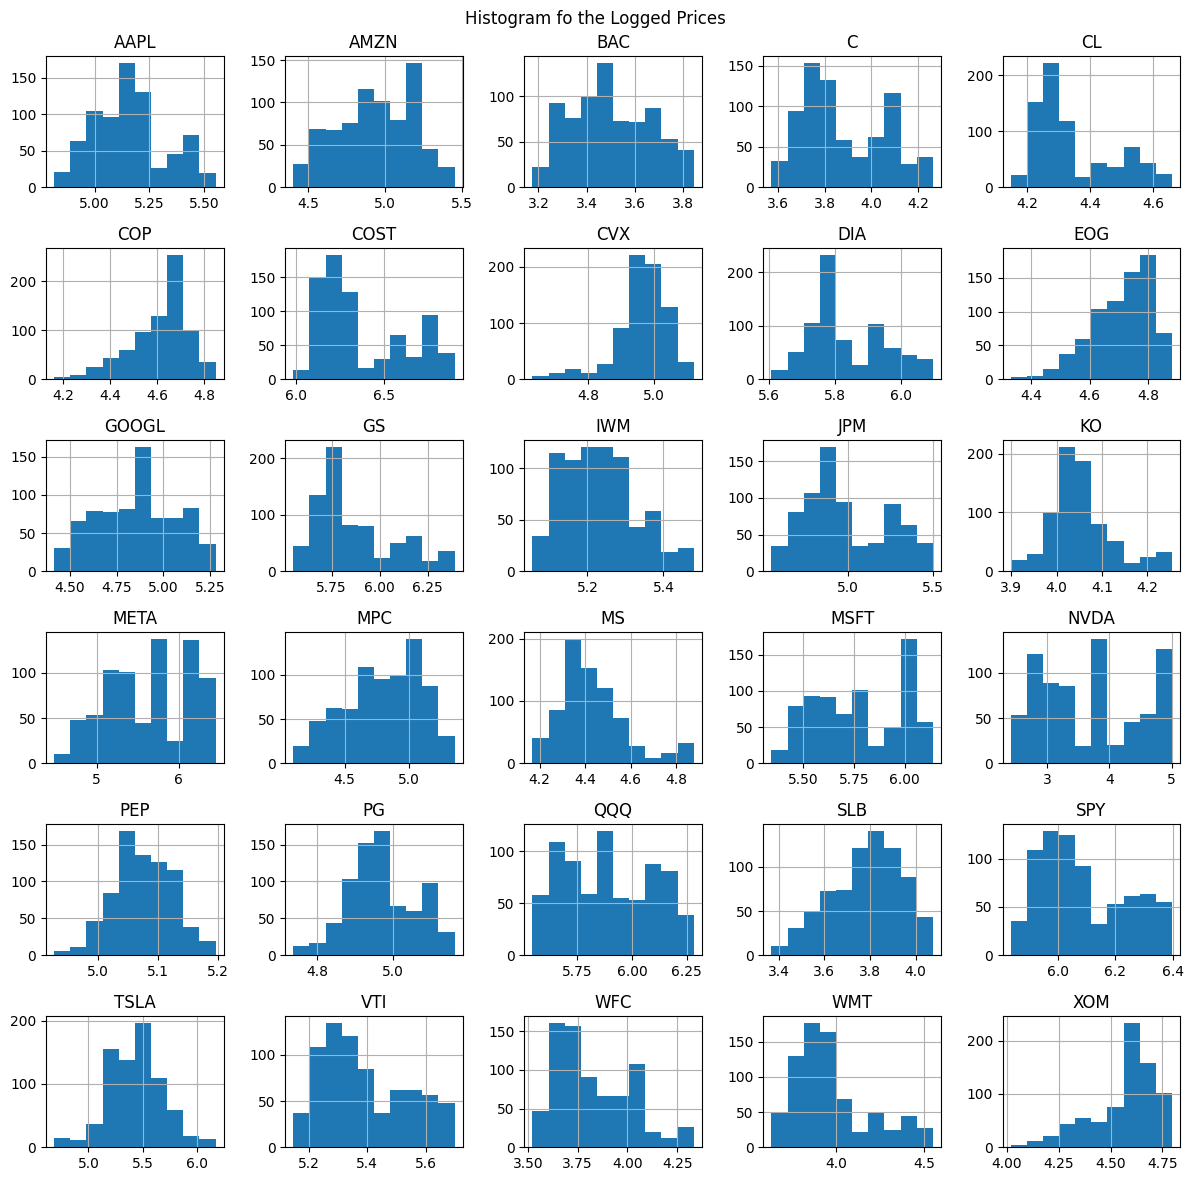

In [13]:
np.log(close_df).hist(figsize=(12, 12))
plt.suptitle('Histogram fo the Logged Prices')
plt.tight_layout()

# Checking on Stationarity

In [8]:
p_value = 0.05

num_stationary = 0
for stock in close_df.columns:
    differenced_log_stock = np.log(close_df[stock]).diff().dropna()
    adf_res = adfuller(differenced_log_stock)
    is_stationary_adf = adf_res[1] < p_value

    kpss_res = kpss(differenced_log_stock)
    is_stationary_kpss = kpss_res[1] > p_value
    
    if is_stationary_adf and is_stationary_kpss:
        #print(f'{stock} is stationary')
        num_stationary += 1

print(f'{num_stationary} stocks are stationary')


29 stocks are stationary


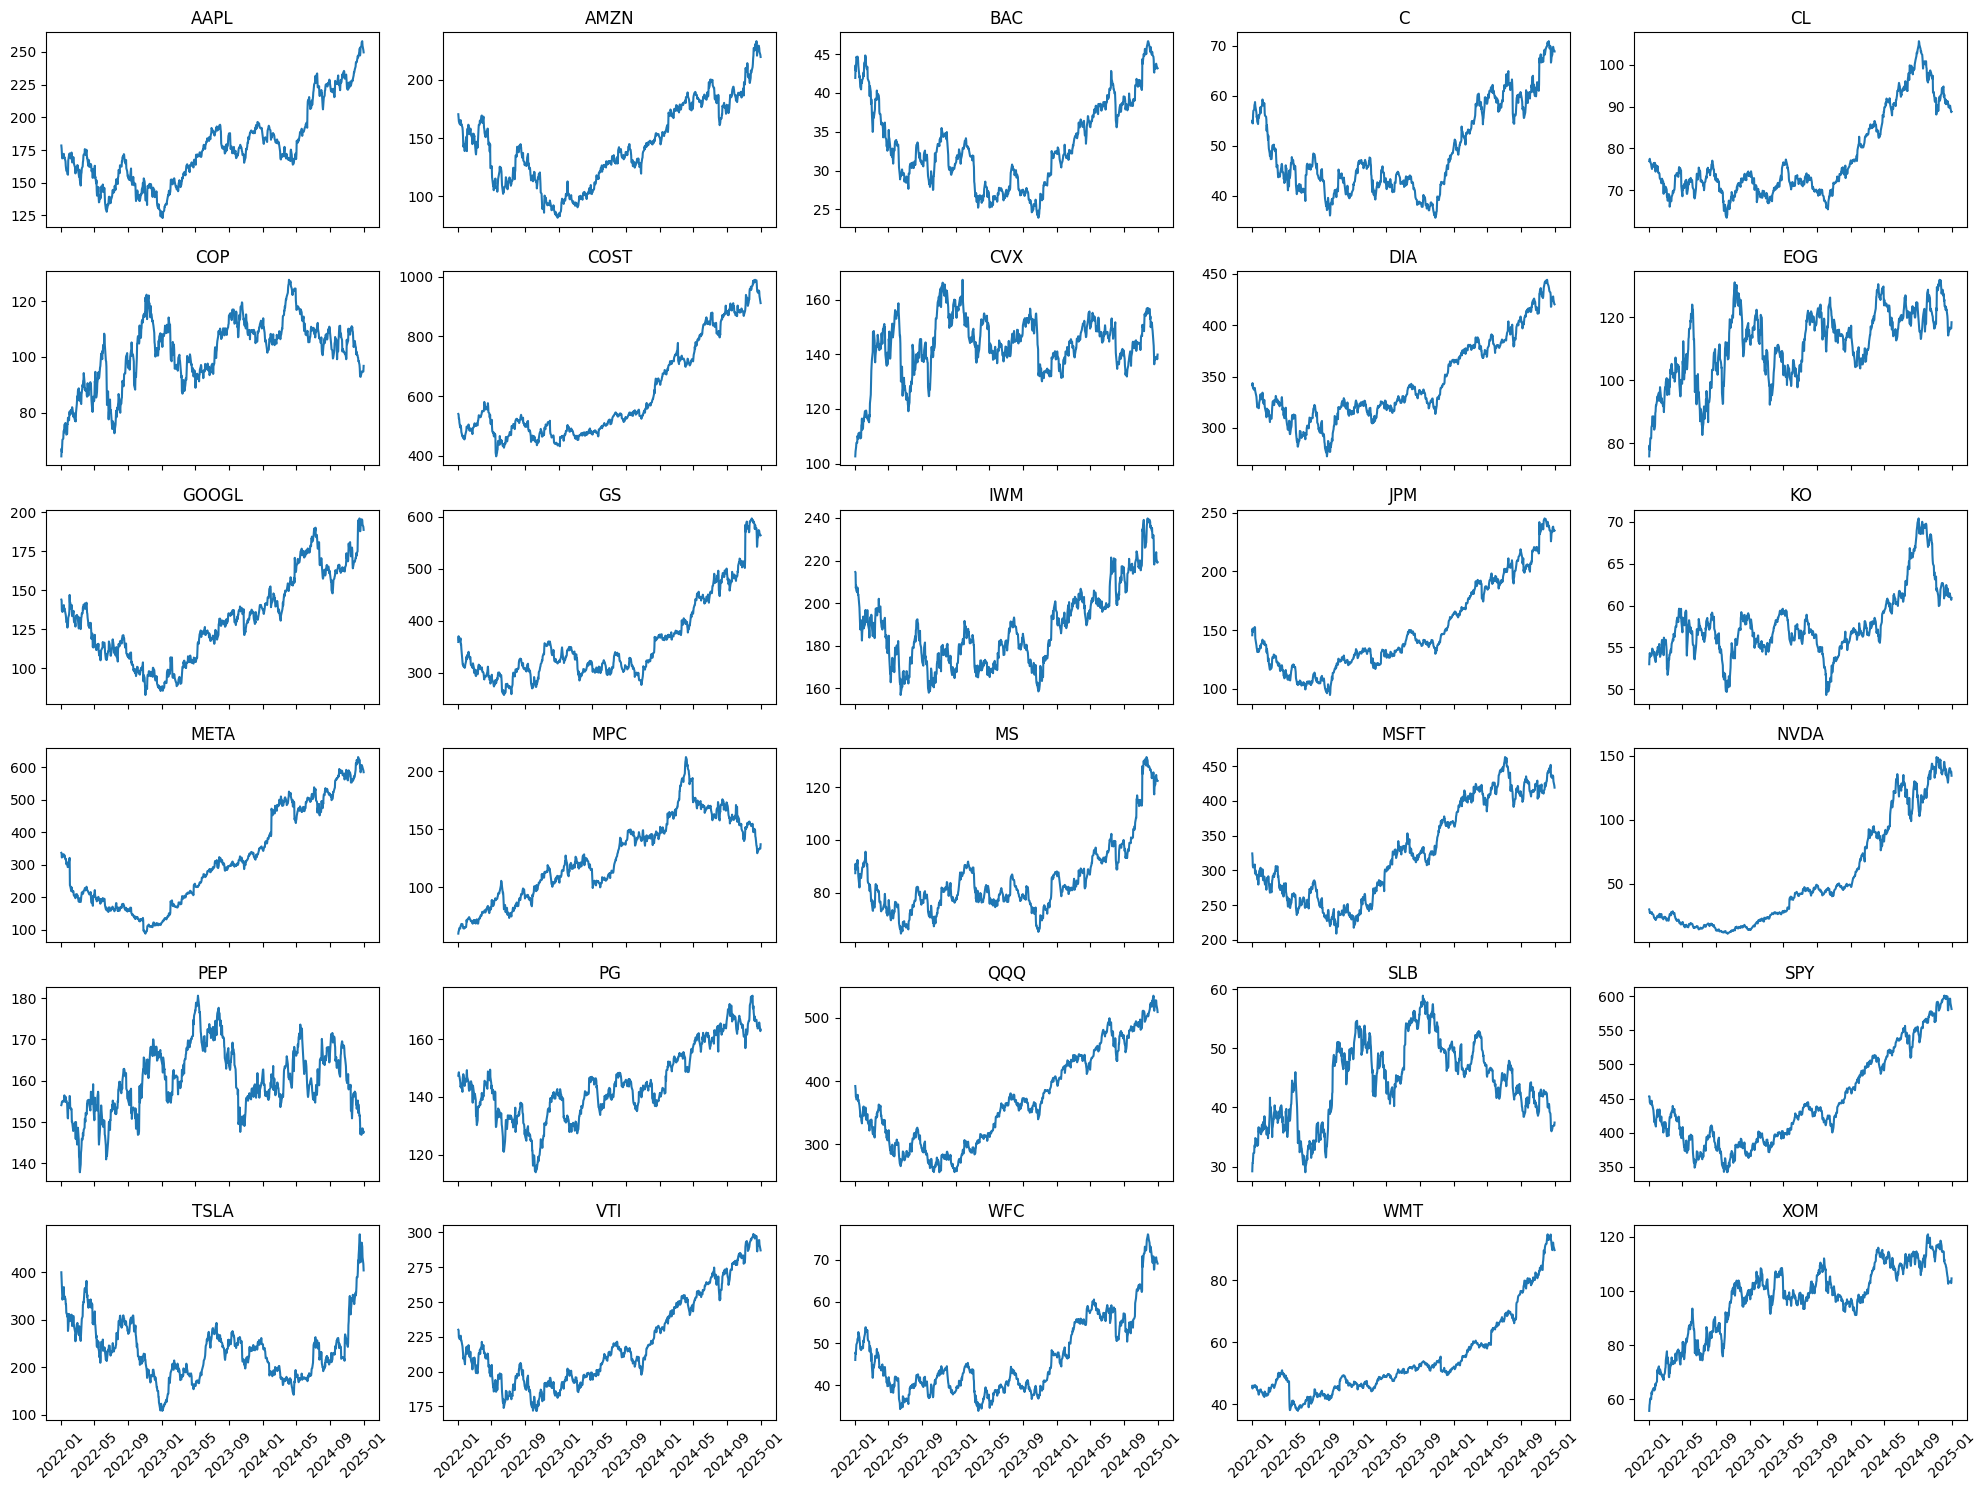

In [33]:
fig, axes = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axes.flatten(), close_df.columns):
    ax.plot(close_df[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


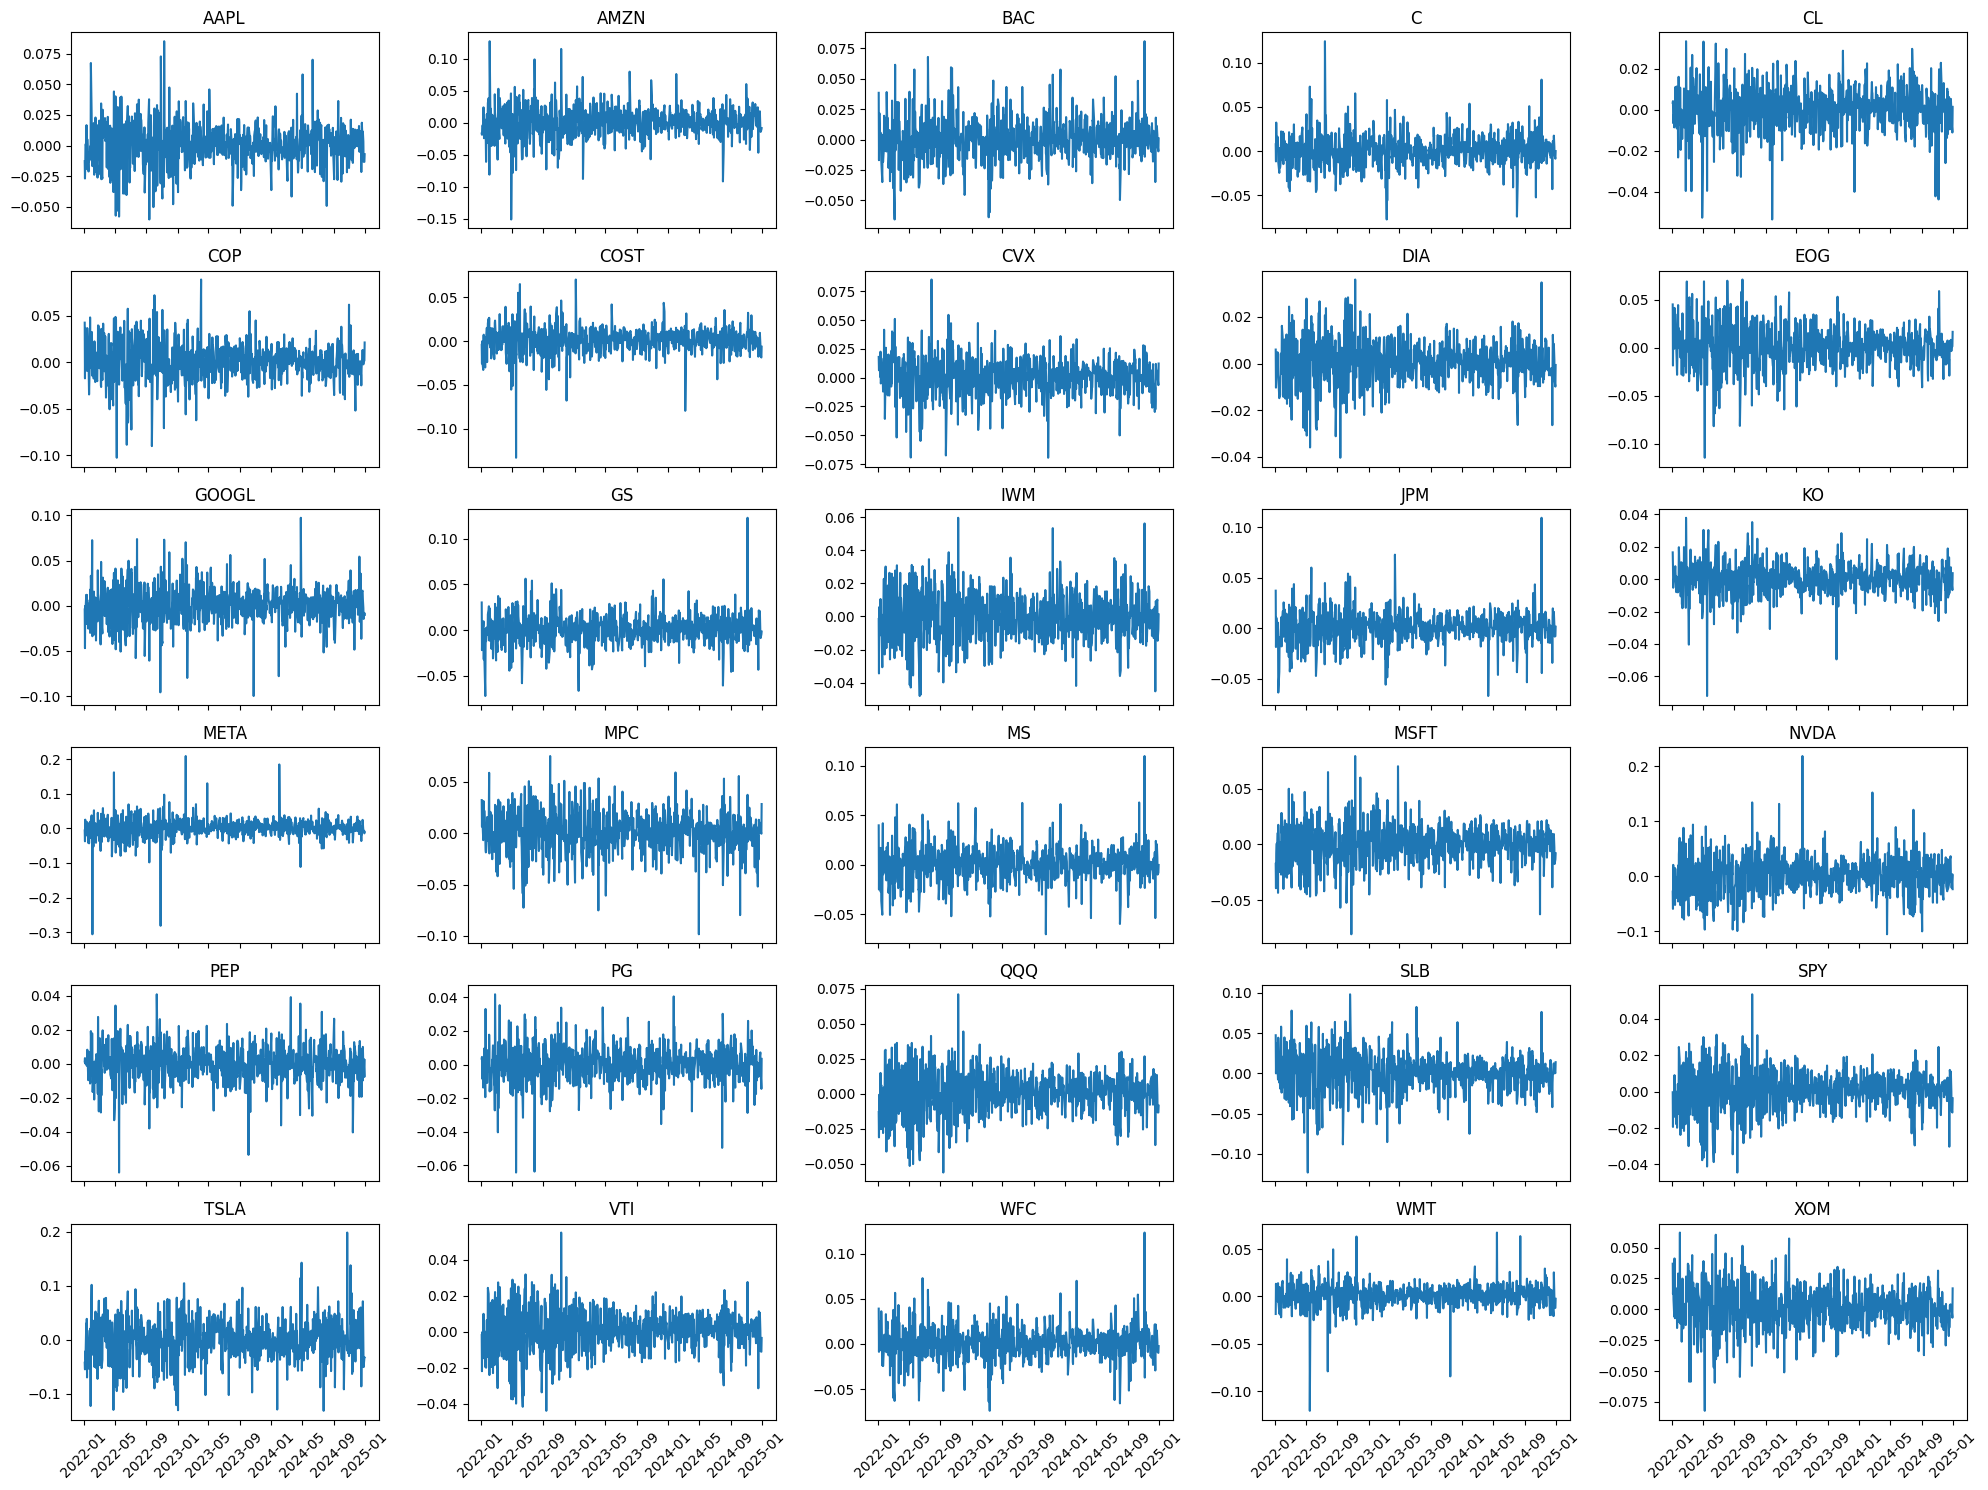

In [162]:
fig, axes = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axes.flatten(), close_df.columns):
    ax.plot(np.log(close_df[stock]).diff().dropna())
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axes.flatten(), close_df.columns):
    ax.plot(np.log(close_df[stock]).diff().dropna())
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [165]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Prepare the data
# -----------------------------
# Compute log returns
log_returns = np.log(close_df).diff().dropna()

# Optional: select a subset of stocks to keep it simple
stocks_subset = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
data = log_returns[stocks_subset]

# -----------------------------
# 2️⃣ Fit VAR model
# -----------------------------
model = VAR(data)

# Select optimal lag based on AIC
lag_order = model.select_order(maxlags=10).aic
print(f"Selected lag order: {lag_order}")

# Fit the model
var_result = model.fit(lag_order)


Selected lag order: 0


In [166]:
# -----------------------------
# 3️⃣ Forecast
# -----------------------------
# Forecast next 5 steps
forecast_steps = 5
forecast = var_result.forecast(data.values[-lag_order:], steps=forecast_steps)

# Convert forecast to DataFrame
forecast_df = pd.DataFrame(forecast, columns=stocks_subset)
print(forecast_df)

# -----------------------------
# 4️⃣ Plot forecasts
# -----------------------------
plt.figure(figsize=(12,6))
for stock in stocks_subset:
    plt.plot(data[stock].iloc[-50:], label=f'Actual {stock}')
    plt.plot(range(len(data), len(data)+forecast_steps), forecast_df[stock], 
             marker='o', linestyle='--', label=f'Forecast {stock}')
plt.legend()
plt.title("VAR Forecast of Stock Log Returns")
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [168]:
data.values

array([[-0.0127728 , -0.01729587, -0.00409119, -0.01706029, -0.00595494],
       [-0.02696006, -0.0391441 , -0.04696179, -0.01907385, -0.03741914],
       [-0.01683426, -0.0079333 , -0.00019974, -0.0067336 ,  0.02525136],
       ...,
       [-0.0133306 , -0.01745301, -0.01462599, -0.01464091, -0.0058846 ],
       [-0.01335217, -0.01332793, -0.00791655, -0.0110101 , -0.01439095],
       [-0.00708289, -0.00786937, -0.01019615, -0.0086683 , -0.00973871]])